# Home task: pytorch

## Import Libraries


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tqdm import tqdm

##  Device Configuration

Selecting CUDA GPU if available, otherwise falling back to CPU. All tensors and the model will be moved to this device during training.

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


##  Load the Dataset

In [14]:
CSV_PATH = 'A_Z Handwritten Data.csv'

df = pd.read_csv(CSV_PATH, header=None)

if not str(df.iloc[0, 0]).isdigit():
    df = df.iloc[1:].reset_index(drop=True)
    df = df.astype(int)

print(f'Total samples : {len(df)}')
print(f'Columns       : {df.shape[1]}  (1 label + 784 pixels)')
print(f'\nLabel distribution (class → count):')
print(df.iloc[:, 0].value_counts().sort_index().to_string())

Total samples : 372451
Columns       : 785  (1 label + 784 pixels)

Label distribution (class → count):
0
0     13870
1      8668
2     23409
3     10134
4     11440
5      1163
6      5762
7      7218
8      1120
9      8493
10     5603
11    11586
12    12336
13    19010
14    57825
15    19341
16     5812
17    11566
18    48419
19    22495
20    29008
21     4182
22    10784
23     6272
24    10859
25     6076


## Custom Dataset: `AlphabetCSVDataset`

Creating a custom `torch.utils.data.Dataset` subclass that wraps the pre-loaded NumPy arrays.  
Each item returns a `float32` feature tensor (normalized to `[0, 1]`) and a `long` label tensor

In [15]:
LABEL_TO_LETTER = {i: chr(ord('A') + i) for i in range(26)}


class AlphabetCSVDataset(Dataset):
    """Dataset wrapping the A-Z Handwritten Alphabet CSV (already split into arrays).

    Args:
        features (np.ndarray): pixel array of shape (N, 784), values 0-255.
        labels   (np.ndarray): integer label array of shape (N,), values 0-25.
    """

    def __init__(self, features: np.ndarray, labels: np.ndarray):
        # Normalise pixels to [0, 1] and cast to float32
        self.features = torch.tensor(features / 255.0, dtype=torch.float32)
        self.labels   = torch.tensor(labels,            dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


dummy_features = np.zeros((5, 784), dtype=np.float32)
dummy_labels   = np.array([0, 1, 2, 3, 4])
dummy_ds       = AlphabetCSVDataset(dummy_features, dummy_labels)
x_sample, y_sample = dummy_ds[0]
print(f'Feature tensor shape : {x_sample.shape}   dtype: {x_sample.dtype}')
print(f'Label  tensor        : {y_sample}          dtype: {y_sample.dtype}')

Feature tensor shape : torch.Size([784])   dtype: torch.float32
Label  tensor        : 0          dtype: torch.int64


## Train / Test Split and DataLoaders

Splitting the full dataset 80 / 20 with `sklearn.train_test_split` (stratified so each letter appears proportionally in both splits), then wrapping both halves in `DataLoader` instances.

In [16]:
BATCH_SIZE = 256

X_all = df.iloc[:, 1:].values.astype(np.float32)
y_all = df.iloc[:, 0].values.astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

train_dataset = AlphabetCSVDataset(X_train, y_train)
test_dataset  = AlphabetCSVDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train samples : {len(train_dataset):>7,}')
print(f'Test  samples : {len(test_dataset):>7,}')
print(f'Train batches : {len(train_loader):>7,}  (batch_size={BATCH_SIZE})')
print(f'Test  batches : {len(test_loader):>7,}  (batch_size={BATCH_SIZE})')

X_batch, y_batch = next(iter(train_loader))
print(f'\nBatch feature shape : {X_batch.shape}')
print(f'Batch label shape   : {y_batch.shape}')

Train samples : 297,960
Test  samples :  74,491
Train batches :   1,164  (batch_size=256)
Test  batches :     291  (batch_size=256)

Batch feature shape : torch.Size([256, 784])
Batch label shape   : torch.Size([256])


## Model Architecture: `AlphabetModel`

Defining a fully-connected (Dense) neural network inheriting from `nn.Module`, closely following the lecture style (`nn.Sequential` inside `linear_relu_stack`).  
The architecture uses **BatchNorm** and **Dropout** for regularisation and faster convergence:

In [17]:
class AlphabetModel(nn.Module):
    def __init__(self, input_size: int, output_size: int):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, output_size),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits


INPUT_SIZE  = 784   # 28 × 28 pixels
OUTPUT_SIZE = 26    # A–Z

model = AlphabetModel(INPUT_SIZE, OUTPUT_SIZE).to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

AlphabetModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=256, out_features=26, bias=True)
  )
)

Trainable parameters: 1,470,234


## Loss Function, Optimizer & Hyperparameters

Setting up `CrossEntropyLoss` for multi-class classification and the `Adam` optimizer, then defining all remaining training hyperparameters.

In [18]:
LEARNING_RATE = 1e-3
EPOCHS        = 15

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Optional: reduce LR when validation loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True
)

print(f'Loss function : {loss_fn}')
print(f'Optimizer     : {optimizer.__class__.__name__}, lr={LEARNING_RATE}')
print(f'Epochs        : {EPOCHS}')

Loss function : CrossEntropyLoss()
Optimizer     : Adam, lr=0.001
Epochs        : 15


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## Training & Evaluation Loops

Defining `train_loop` and `test_loop`:
- `model.train()` / `model.eval()` called explicitly
- `tqdm` progress bar with live loss display inside the train loop
- `torch.no_grad()` context manager inside the test loop
- Both functions **return** `(avg_loss, accuracy)` so we can record them for the plots

In [19]:
def train_loop(dataloader, model, loss_fn, optimizer, epoch):
    model.train()

    total_loss = 0.0
    correct    = 0
    total      = 0

    tqdm_loader = tqdm(dataloader, unit='batch', desc=f'Epoch {epoch:>2}', total=len(dataloader))
    for batch, (X, y) in enumerate(tqdm_loader):
        X, y = X.to(device), y.to(device)

        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        correct    += (pred.argmax(1) == y).type(torch.float).sum().item()
        total      += y.size(0)

        tqdm_loader.set_postfix(loss=f'{loss.item():.4f}')

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    return avg_loss, accuracy


def test_loop(dataloader, model, loss_fn):
    model.eval()

    size       = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss  = 0.0
    correct    = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct   += (pred.argmax(1) == y).type(torch.float).sum().item()

    avg_loss = test_loss / num_batches
    accuracy = correct / size
    print(f'Test Error: Accuracy: {100 * accuracy:>0.1f}%,  Avg loss: {avg_loss:>8f}\n')
    return avg_loss, accuracy

## Training

Running the full training loop for `EPOCHS` epochs. After every epoch the train and test metrics are stored in lists so they can be plotted later. The best model weights (by test accuracy) are preserved.

In [20]:
train_loss_history = []
train_acc_history  = []
test_loss_history  = []
test_acc_history   = []

best_test_acc  = 0.0
best_model_wts = None

for epoch in range(EPOCHS):
    train_loss, train_acc = train_loop(train_loader, model, loss_fn, optimizer, epoch)
    test_loss,  test_acc  = test_loop(test_loader,  model, loss_fn)

    scheduler.step(test_loss)

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    test_loss_history.append(test_loss)
    test_acc_history.append(test_acc)

    if test_acc > best_test_acc:
        best_test_acc  = test_acc
        best_model_wts = {k: v.clone() for k, v in model.state_dict().items()}

print(f'\nTraining complete.  Best test accuracy: {100 * best_test_acc:.2f}%')

model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), 'alphabet_model_best.pth')
print('Best model saved to alphabet_model_best.pth')

Epoch  0: 100%|██████████| 1164/1164 [00:09<00:00, 116.89batch/s, loss=0.1021]


Test Error: Accuracy: 97.1%,  Avg loss: 0.096721



Epoch  1: 100%|██████████| 1164/1164 [00:08<00:00, 132.25batch/s, loss=0.0757]


Test Error: Accuracy: 97.9%,  Avg loss: 0.069309



Epoch  2: 100%|██████████| 1164/1164 [00:08<00:00, 134.53batch/s, loss=0.1186]


...

Test Error: Accuracy: 99.2%,  Avg loss: 0.030375



Epoch 13: 100%|██████████| 1164/1164 [00:09<00:00, 121.69batch/s, loss=0.0115]


Test Error: Accuracy: 99.2%,  Avg loss: 0.027124



Epoch 14: 100%|██████████| 1164/1164 [00:09<00:00, 124.55batch/s, loss=0.0318]


Test Error: Accuracy: 99.3%,  Avg loss: 0.026626


Training complete.  Best test accuracy: 99.29%
Best model saved to alphabet_model_best.pth


##  Visualize Loss & Accuracy Curves

Plotting the training and test loss curves, alongside the training and test accuracy curves, over all epochs to inspect learning dynamics.

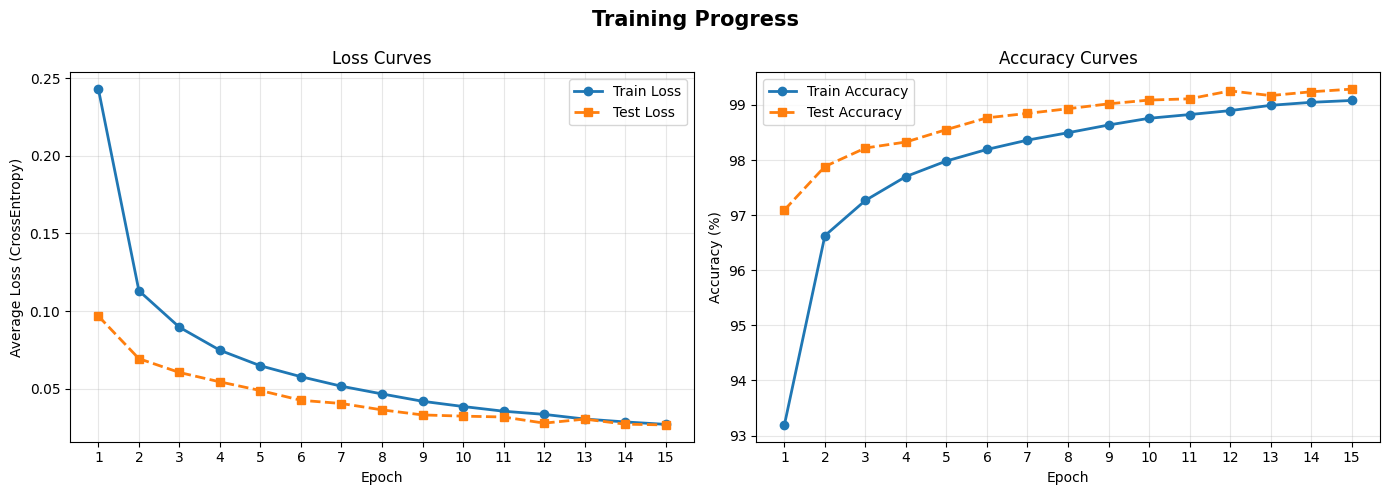

Final  train accuracy : 99.08%
Final  test  accuracy : 99.29%


In [23]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Progress', fontsize=15, fontweight='bold')

axes[0].plot(epochs_range, train_loss_history, label='Train Loss', marker='o', linewidth=2)
axes[0].plot(epochs_range, test_loss_history,  label='Test Loss',  marker='s', linewidth=2, linestyle='--')
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Average Loss (CrossEntropy)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(epochs_range)

axes[1].plot(epochs_range, [a * 100 for a in train_acc_history], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(epochs_range, [a * 100 for a in test_acc_history],  label='Test Accuracy',  marker='s', linewidth=2, linestyle='--')
axes[1].set_title('Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(epochs_range)

plt.tight_layout()
plt.show()
print(f'Final  train accuracy : {100 * train_acc_history[-1]:.2f}%')
print(f'Final  test  accuracy : {100 * test_acc_history[-1]:.2f}%')

## Visualize 10 Random Test Predictions

Randomly sampling 10 items from the test set, running inference with `torch.no_grad()`, and displaying each 28×28 image alongside the **true** and **predicted** letter labels.  

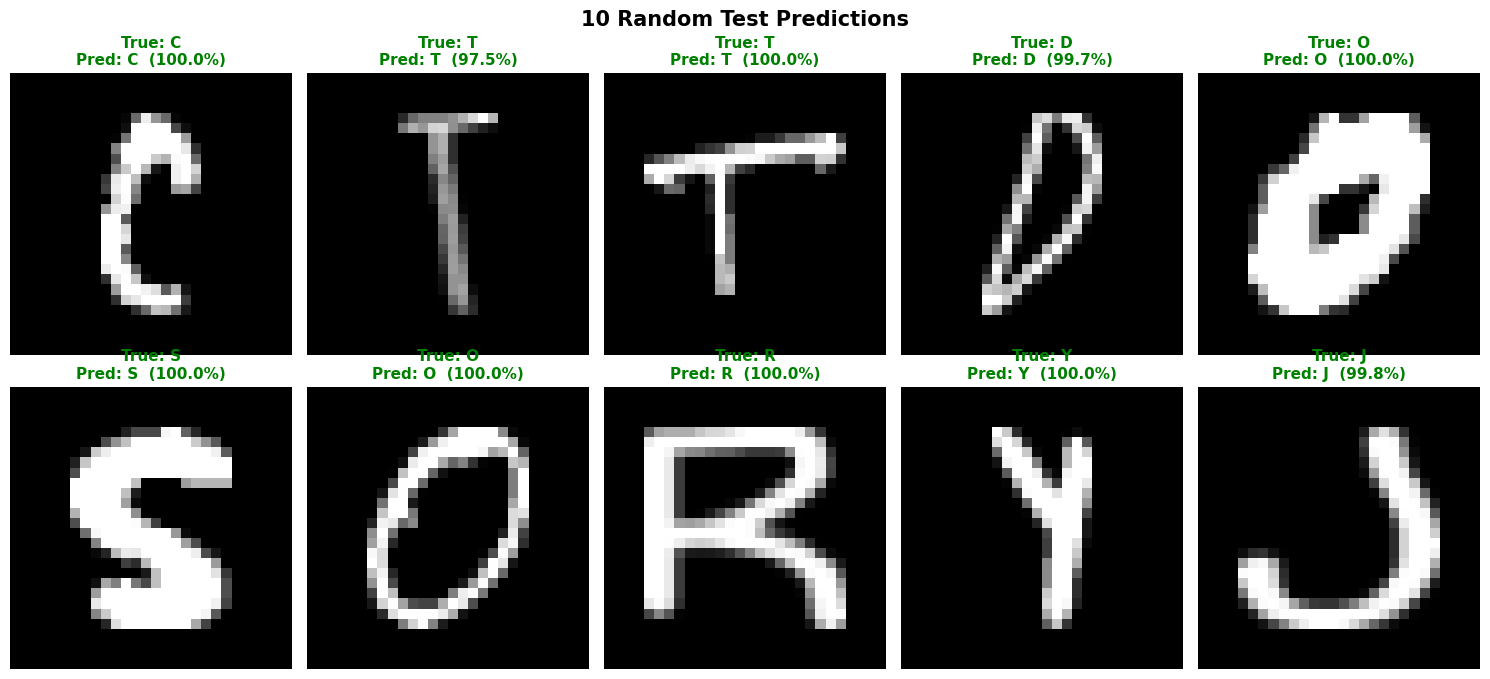

Correct predictions in this sample: 10 / 10


In [24]:
NUM_SAMPLES = 10

random_indices = np.random.choice(len(test_dataset), size=NUM_SAMPLES, replace=False)

sample_features = torch.stack([test_dataset[i][0] for i in random_indices]).to(device)  # (10, 784)
sample_labels   = [test_dataset[i][1].item()       for i in random_indices]

model.eval()
with torch.no_grad():
    logits       = model(sample_features)            # (10, 26)
    probs        = torch.softmax(logits, dim=1)      # (10, 26)
    pred_labels  = torch.argmax(probs, dim=1).cpu().numpy()  # (10,)
    confidences  = probs.max(dim=1).values.cpu().numpy()     # (10,)

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle('10 Random Test Predictions', fontsize=15, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img = sample_features[i].cpu().numpy().reshape(28, 28)

    true_letter = LABEL_TO_LETTER[sample_labels[i]]
    pred_letter = LABEL_TO_LETTER[pred_labels[i]]
    confidence  = confidences[i] * 100
    is_correct  = (sample_labels[i] == pred_labels[i])

    ax.imshow(img, cmap='gray')
    ax.axis('off')

    title_color = 'green' if is_correct else 'red'
    ax.set_title(
        f'True: {true_letter}\nPred: {pred_letter}  ({confidence:.1f}%)',
        color=title_color,
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

n_correct = sum(sample_labels[i] == pred_labels[i] for i in range(NUM_SAMPLES))
print(f'Correct predictions in this sample: {n_correct} / {NUM_SAMPLES}')